# Effective Potential of the Standard Model

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from Standard_Model import Standard_Model

In [2]:
model = Standard_Model()
v = model.v_os

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), 0.0).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.5f} GeV")
print(f"CW shift: {abs(v_num - v)/v * 100:.5f}%")

Numerical vev (Vtot, T=0): 246.22000 GeV
CW shift: 0.00000%


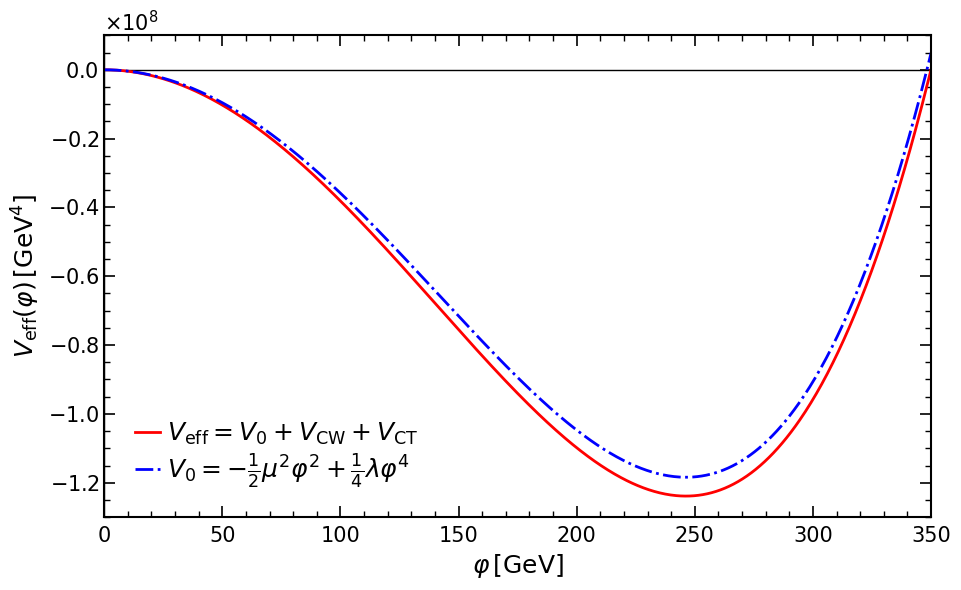

In [3]:
phi_vals = np.linspace(-350, 350, 1500)
X        = phi_vals[:, np.newaxis]

VTL   = model.V0(X)
Veff  = model.Vtot(X, 0.0)
VTL0   = model.V0(np.array([[0.0]]))
Veff0  = model.Vtot(np.array([[0.0]]), 0.0)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, Veff-Veff0, label=r'$V_{\mathrm{eff}}=V_0+V_\mathrm{CW}+V_\mathrm{CT}$', color='r', lw=2, ls='-')
ax.plot(phi_vals, VTL-VTL0, label=r'$V_0=-\frac{1}{2}\mu^2\varphi^2+\frac{1}{4}\lambda\varphi^4$', color='b', lw=2, ls='-.')

ax.set_xlim(0, 350)
ax.set_ylim(-1.3e8, 0.1e8)

ax.set_xlabel(r'$\varphi \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"SM_Veff.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [3]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [246.22000114] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
....................................................................................................................................................................................................................................................................................................................
Tracing phase starting at x = [-8.67361738e-19] ; t = 192.79132737412272
Tracing minimum down
traceMinimum t0 = 192.791
..........................
Tracing minimum up
traceMinimum t0 = 192.791
.........
Tc = 191.7601 GeV  |  xi_c = 0.13


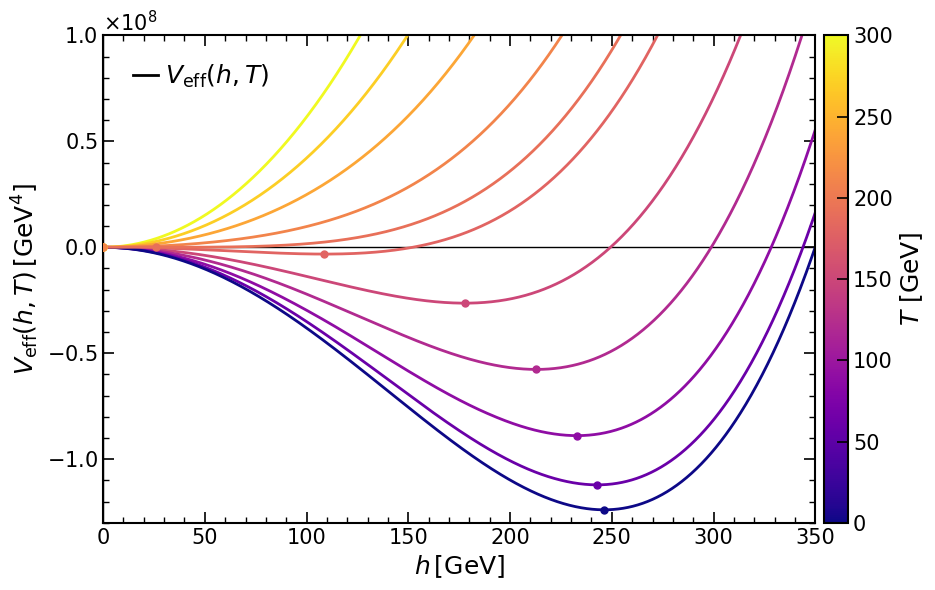

In [5]:
phi_vals = np.linspace(-50, 350, 1500)
X        = phi_vals[:, np.newaxis]
T_vals   = np.array([300.        , 270.        , 240.        , 210.        ,
       180.        , 150.        , 120.        ,  90.        ,
        60.        ,   0.        , 191.76014412])

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
        color = cmap(norm(T))
        Veff  = model.Vtot(X, T)
        Veff0  = model.Vtot(np.array([[0.0]]), T)
        ax.plot(phi_vals, Veff-Veff0, label=r'$V_{\mathrm{eff}}(\varphi , T)$', color=color, lw=2, ls='-')

        mask = phi_vals > 0
        idx  = np.argmin(Veff[mask])
        phi_min = phi_vals[mask][idx]
        V_min   = Veff[mask][idx]
        ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5, zorder=10)


ax.set_xlim(0, 350)
ax.set_ylim(-1.3e8, 1e8)

ax.set_xlabel(r'$h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(h, T) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

handles_list = [mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=1, label=r"$V_{\mathrm{eff}}(h , T)$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"SM_Thermal_Evolution_Presentation.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [6]:
phases = model.getPhases()

Tracing phase starting at x = [246.22000114] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
....................................................................................................................................................................................................................................................................................................................
Tracing phase starting at x = [-8.67361738e-19] ; t = 192.79132737412272
Tracing minimum down
traceMinimum t0 = 192.791
..........................
Tracing minimum up
traceMinimum t0 = 192.791
.........


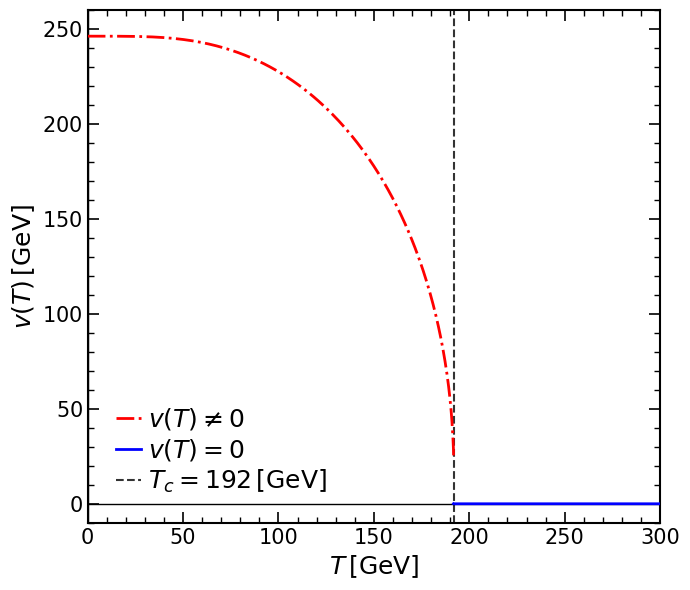

In [8]:
T_sym = phases[1].T
X_sym = phases[1].X

T_brk = phases[0].T
X_brk = phases[0].X

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(T_brk, X_brk, label=r'$v(T)\neq 0$', color='r', lw=2, ls='-.', zorder=10)
ax.plot(T_sym, X_sym, label=r'$v(T) = 0$', color='b', lw=2, ls='-', zorder=10)
#ax.axvline(T_brk[-1], label=rf'$T_1={T_brk[-1]:.0f} \, [\mathrm{{GeV}}]$', color='k', lw=1.5, ls='--', alpha=0.8)
ax.axvline(Tc, label=rf'$T_c={Tc:.0f} \, [\mathrm{{GeV}}]$', color='k', lw=1.5, ls='--', alpha=0.8)
#ax.axvline(T_sym[0], label=rf'$T_0={T_sym[0]:.0f} \, [\mathrm{{GeV}}]$', color='k', lw=1.5, ls=':', alpha=0.8)

ax.set_xlim(0, 300)
ax.set_ylim(-10, 260)

ax.set_xlabel(r'$T \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$v(T)\, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 3))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=8)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"SM_Thermal_VEV_Presentation.pdf", format="pdf", bbox_inches="tight")
plt.show()